# Predicting Student Health Risk

## Tree-Based Model Development

This notebook develops and compares Decision Tree, Random Forest, and XGBoost models. All models use the same training data, validation data, and preprocessing pipeline. The main evaluation measurement is balanced accuracy because the target classes may be imbalanced.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

from xgboost import XGBClassifier

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_folder = current_folder
else:
    project_folder = current_folder.parent

data_folder = project_folder / "data" / "kaggle" / "raw"
models_folder = project_folder / "models"
results_folder = project_folder / "outputs" / "results"
figures_folder = project_folder / "outputs" / "figures"

models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Project folder")
print(project_folder)

Project folder
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project


In [4]:
train_file = data_folder / "train.csv"
preprocessor_file = models_folder / "preprocessing_pipeline.joblib"
column_file = models_folder / "column_information.joblib"

print("Training file exists", train_file.exists())
print("Preprocessor exists", preprocessor_file.exists())
print("Column information exists", column_file.exists())

Training file exists True
Preprocessor exists True
Column information exists True


In [5]:
train_data = pd.read_csv(train_file)

column_information = joblib.load(column_file)

print("Training data loaded successfully")
print("Training data shape", train_data.shape)

Training data loaded successfully
Training data shape (690088, 15)


In [6]:
target_column = column_information["target_column"]
identifier_columns = column_information["identifier_columns"]

X = train_data.drop(columns=[target_column])
y = train_data[target_column]

if len(identifier_columns) > 0:
    X = X.drop(columns=identifier_columns)

print("Input feature shape", X.shape)
print("Target shape", y.shape)

print()

print("Target classes")
print(y.unique())

Input feature shape (690088, 13)
Target shape (690088,)

Target classes
<StringArray>
['unhealthy', 'at-risk', 'fit']
Length: 3, dtype: str


In [7]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training input shape", X_train.shape)
print("Validation input shape", X_validation.shape)

print()

print("Training target distribution")
print(y_train.value_counts(normalize=True).round(3))

print()

print("Validation target distribution")
print(y_validation.value_counts(normalize=True).round(3))

Training input shape (552070, 13)
Validation input shape (138018, 13)

Training target distribution
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64

Validation target distribution
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64


In [8]:
tree_preprocessor = joblib.load(preprocessor_file)

decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [9]:
tree_train_predictions = decision_tree_model.predict(
    X_train
)

tree_validation_predictions = decision_tree_model.predict(
    X_validation
)

print("Decision Tree predictions completed")

Decision Tree predictions completed


In [10]:
tree_train_balanced_accuracy = balanced_accuracy_score(
    y_train,
    tree_train_predictions
)

tree_validation_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    tree_validation_predictions
)

tree_accuracy = accuracy_score(
    y_validation,
    tree_validation_predictions
)

tree_macro_f1 = f1_score(
    y_validation,
    tree_validation_predictions,
    average="macro"
)

print("Training balanced accuracy")
print(round(tree_train_balanced_accuracy, 4))

print()

print("Validation balanced accuracy")
print(round(tree_validation_balanced_accuracy, 4))

print()

print("Normal accuracy")
print(round(tree_accuracy, 4))

print()

print("Macro F1 score")
print(round(tree_macro_f1, 4))

Training balanced accuracy
0.9026

Validation balanced accuracy
0.902

Normal accuracy
0.8558

Macro F1 score
0.7308


In [11]:
print(
    classification_report(
        y_validation,
        tree_validation_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     at-risk       0.99      0.84      0.91    118512
         fit       0.46      0.91      0.61      7961
   unhealthy       0.52      0.95      0.67     11545

    accuracy                           0.86    138018
   macro avg       0.66      0.90      0.73    138018
weighted avg       0.92      0.86      0.87    138018



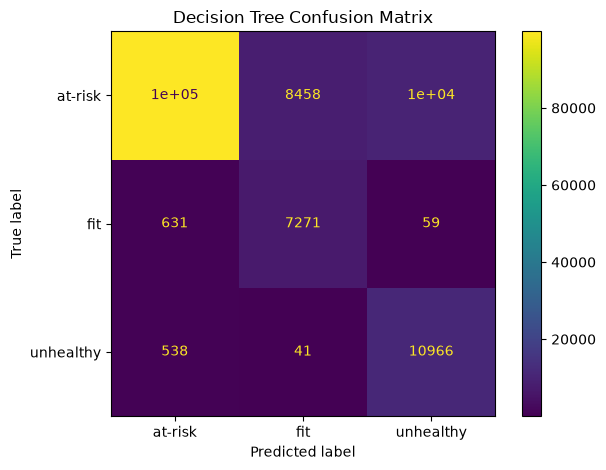

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    tree_validation_predictions
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()

tree_figure = figures_folder / "tree_based_decision_tree_confusion_matrix.png"

plt.savefig(tree_figure)
plt.show()

In [13]:
forest_preprocessor = joblib.load(preprocessor_file)

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            forest_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully")

Random Forest trained successfully


In [14]:
forest_train_predictions = random_forest_model.predict(
    X_train
)

forest_validation_predictions = random_forest_model.predict(
    X_validation
)

print("Random Forest predictions completed")

Random Forest predictions completed


In [15]:
forest_train_balanced_accuracy = balanced_accuracy_score(
    y_train,
    forest_train_predictions
)

forest_validation_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    forest_validation_predictions
)

forest_accuracy = accuracy_score(
    y_validation,
    forest_validation_predictions
)

forest_macro_f1 = f1_score(
    y_validation,
    forest_validation_predictions,
    average="macro"
)

print("Training balanced accuracy")
print(round(forest_train_balanced_accuracy, 4))

print()

print("Validation balanced accuracy")
print(round(forest_validation_balanced_accuracy, 4))

print()

print("Normal accuracy")
print(round(forest_accuracy, 4))

print()

print("Macro F1 score")
print(round(forest_macro_f1, 4))

Training balanced accuracy
0.9175

Validation balanced accuracy
0.9054

Normal accuracy
0.8927

Macro F1 score
0.7787


In [16]:
print(
    classification_report(
        y_validation,
        forest_validation_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     at-risk       0.98      0.89      0.93    118512
         fit       0.52      0.91      0.67      7961
   unhealthy       0.62      0.91      0.74     11545

    accuracy                           0.89    138018
   macro avg       0.71      0.91      0.78    138018
weighted avg       0.93      0.89      0.90    138018



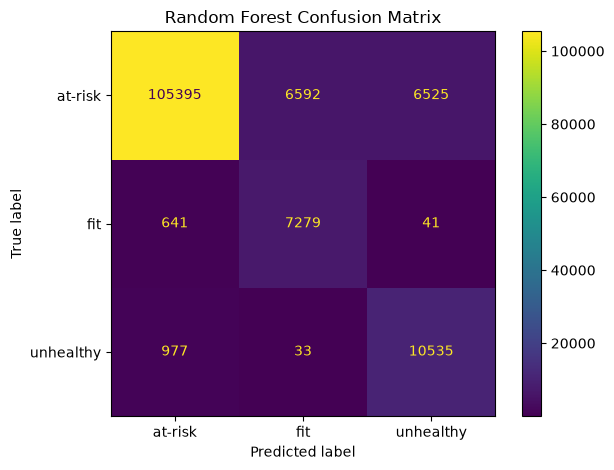

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    forest_validation_predictions
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

forest_figure = figures_folder / "random_forest_confusion_matrix.png"

plt.savefig(forest_figure)
plt.show()

In [18]:
forest_feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

forest_importance_values = random_forest_model.named_steps[
    "classifier"
].feature_importances_

forest_importance = pd.DataFrame(
    {
        "Feature": forest_feature_names,
        "Importance": forest_importance_values
    }
)

forest_importance = forest_importance.sort_values(
    by="Importance",
    ascending=False
)

forest_importance.head(15)

,Feature,Importance
0,numerical__sleep_duration,0.308260
10,categorical__stress_level_high,0.185631
11,categorical__stress_level_low,0.152057
16,categorical__physical_activity_level_active,0.116162
12,categorical__stress_level_medium,0.070859
2,numerical__bmi,0.034670
18,categorical__physical_activity_level_sedentary,0.032386
17,categorical__physical_activity_level_moderate,0.021930
4,numerical__step_count,0.019012
5,numerical__exercise_duration,0.018749


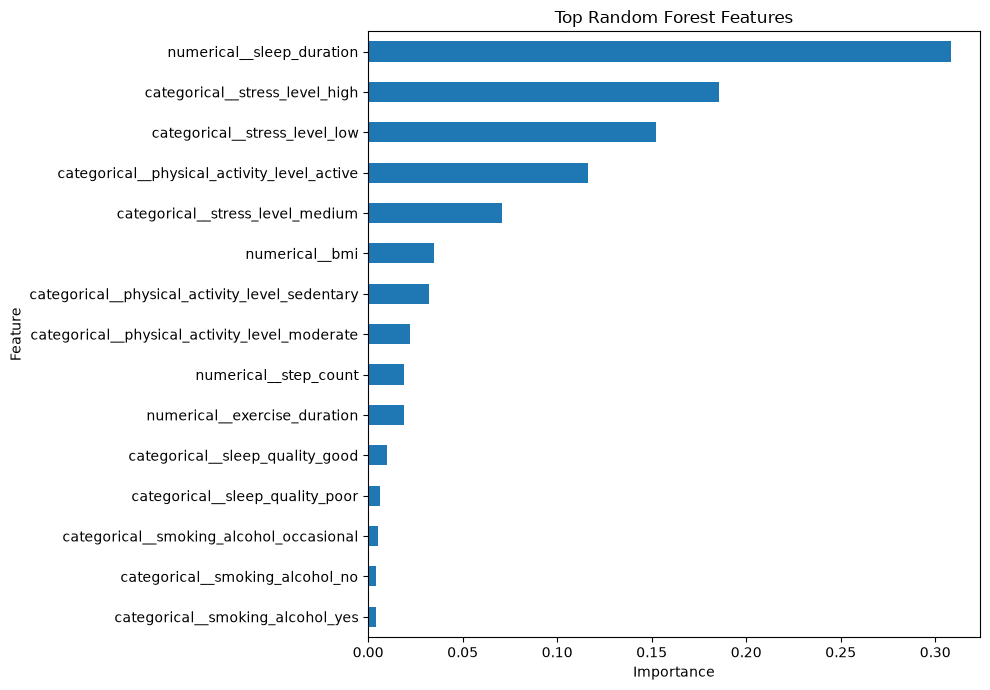

In [19]:
top_forest_features = forest_importance.head(15).sort_values(
    by="Importance"
)

top_forest_features.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Top Random Forest Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

forest_importance_figure = figures_folder / "random_forest_feature_importance.png"

plt.savefig(forest_importance_figure)
plt.show()

In [20]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_validation_encoded = label_encoder.transform(
    y_validation
)

print("Encoded target classes")

for number, class_name in enumerate(label_encoder.classes_):
    print(number, class_name)

Encoded target classes
0 at-risk
1 fit
2 unhealthy


In [21]:
xgboost_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

print("Sample weights created successfully")
print("Number of sample weights", len(xgboost_sample_weights))

Sample weights created successfully
Number of sample weights 552070


In [22]:
xgboost_preprocessor = joblib.load(preprocessor_file)

xgboost_model = Pipeline(
    steps=[
        (
            "preprocessor",
            xgboost_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.80,
                colsample_bytree=0.80,
                objective="multi:softprob",
                eval_metric="mlogloss",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgboost_model.fit(
    X_train,
    y_train_encoded,
    classifier__sample_weight=xgboost_sample_weights
)

print("XGBoost trained successfully")

XGBoost trained successfully


In [23]:
xgboost_train_encoded = xgboost_model.predict(
    X_train
).astype(int)

xgboost_validation_encoded = xgboost_model.predict(
    X_validation
).astype(int)

xgboost_train_predictions = label_encoder.inverse_transform(
    xgboost_train_encoded
)

xgboost_validation_predictions = label_encoder.inverse_transform(
    xgboost_validation_encoded
)

print("XGBoost predictions completed")

XGBoost predictions completed


In [24]:
xgboost_train_balanced_accuracy = balanced_accuracy_score(
    y_train,
    xgboost_train_predictions
)

xgboost_validation_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    xgboost_validation_predictions
)

xgboost_accuracy = accuracy_score(
    y_validation,
    xgboost_validation_predictions
)

xgboost_macro_f1 = f1_score(
    y_validation,
    xgboost_validation_predictions,
    average="macro"
)

print("Training balanced accuracy")
print(round(xgboost_train_balanced_accuracy, 4))

print()

print("Validation balanced accuracy")
print(round(xgboost_validation_balanced_accuracy, 4))

print()

print("Normal accuracy")
print(round(xgboost_accuracy, 4))

print()

print("Macro F1 score")
print(round(xgboost_macro_f1, 4))

Training balanced accuracy
0.9113

Validation balanced accuracy
0.9097

Normal accuracy
0.873

Macro F1 score
0.7541


In [25]:
print(
    classification_report(
        y_validation,
        xgboost_validation_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     at-risk       0.99      0.86      0.92    118512
         fit       0.50      0.93      0.65      7961
   unhealthy       0.55      0.94      0.69     11545

    accuracy                           0.87    138018
   macro avg       0.68      0.91      0.75    138018
weighted avg       0.92      0.87      0.89    138018



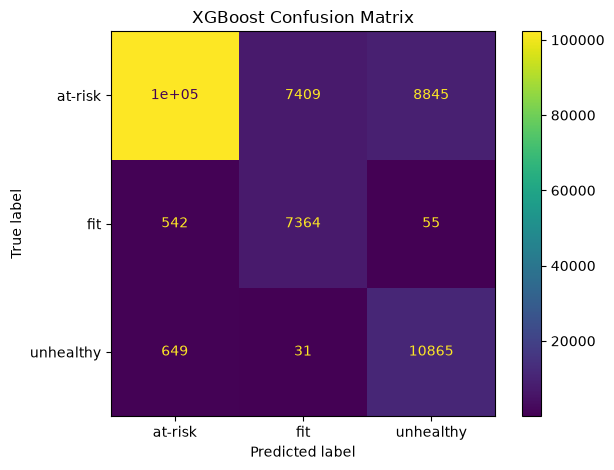

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    xgboost_validation_predictions
)

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()

xgboost_figure = figures_folder / "xgboost_confusion_matrix.png"

plt.savefig(xgboost_figure)
plt.show()

In [27]:
xgboost_feature_names = xgboost_model.named_steps[
    "preprocessor"
].get_feature_names_out()

xgboost_importance_values = xgboost_model.named_steps[
    "classifier"
].feature_importances_

xgboost_importance = pd.DataFrame(
    {
        "Feature": xgboost_feature_names,
        "Importance": xgboost_importance_values
    }
)

xgboost_importance = xgboost_importance.sort_values(
    by="Importance",
    ascending=False
)

xgboost_importance.head(15)

,Feature,Importance
11,categorical__stress_level_low,0.234172
12,categorical__stress_level_medium,0.190663
16,categorical__physical_activity_level_active,0.144085
10,categorical__stress_level_high,0.122301
0,numerical__sleep_duration,0.096726
18,categorical__physical_activity_level_sedentary,0.068597
17,categorical__physical_activity_level_moderate,0.060362
20,categorical__smoking_alcohol_occasional,0.029239
14,categorical__sleep_quality_good,0.013277
2,numerical__bmi,0.006588


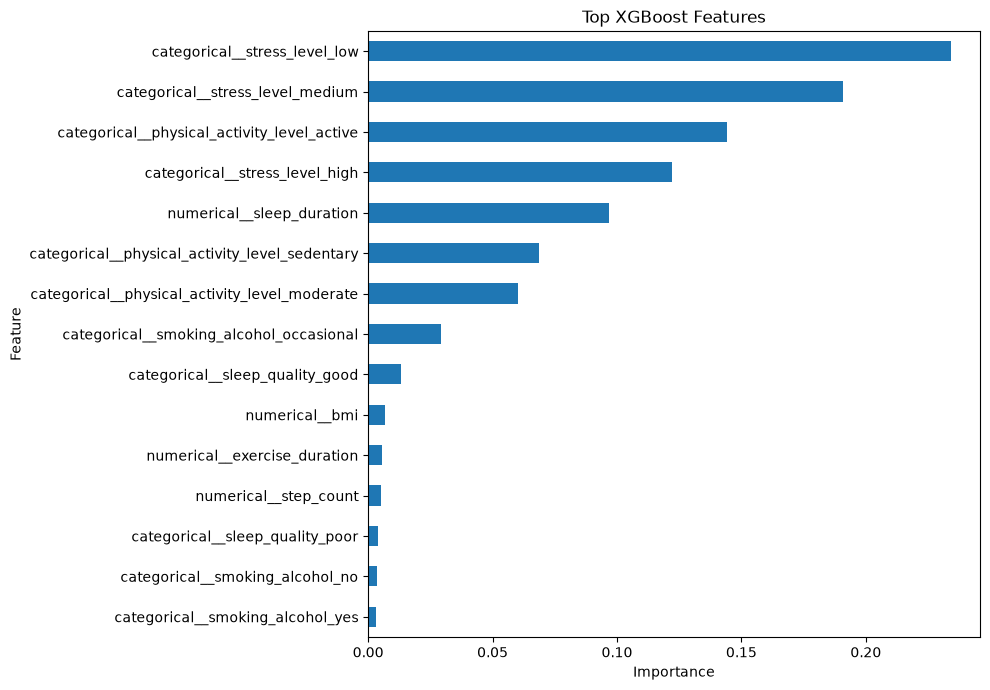

In [28]:
top_xgboost_features = xgboost_importance.head(15).sort_values(
    by="Importance"
)

top_xgboost_features.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Top XGBoost Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

xgboost_importance_figure = figures_folder / "xgboost_feature_importance.png"

plt.savefig(xgboost_importance_figure)
plt.show()

In [29]:
tree_model_comparison = pd.DataFrame(
    {
        "Model": [
            "Decision Tree",
            "Random Forest",
            "XGBoost"
        ],
        "Training Balanced Accuracy": [
            tree_train_balanced_accuracy,
            forest_train_balanced_accuracy,
            xgboost_train_balanced_accuracy
        ],
        "Validation Balanced Accuracy": [
            tree_validation_balanced_accuracy,
            forest_validation_balanced_accuracy,
            xgboost_validation_balanced_accuracy
        ],
        "Normal Accuracy": [
            tree_accuracy,
            forest_accuracy,
            xgboost_accuracy
        ],
        "Macro F1 Score": [
            tree_macro_f1,
            forest_macro_f1,
            xgboost_macro_f1
        ]
    }
)

tree_model_comparison = tree_model_comparison.round(4)

tree_model_comparison

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,Decision Tree,0.9026,0.9020,0.8558,0.7308
1,Random Forest,0.9175,0.9054,0.8927,0.7787
2,XGBoost,0.9113,0.9097,0.8730,0.7541


In [30]:
tree_model_comparison_sorted = tree_model_comparison.sort_values(
    by="Validation Balanced Accuracy",
    ascending=False
)

tree_model_comparison_sorted

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
2,XGBoost,0.9113,0.9097,0.8730,0.7541
1,Random Forest,0.9175,0.9054,0.8927,0.7787
0,Decision Tree,0.9026,0.9020,0.8558,0.7308


In [31]:
best_tree_model_name = tree_model_comparison_sorted.iloc[0]["Model"]

best_tree_score = tree_model_comparison_sorted.iloc[0][
    "Validation Balanced Accuracy"
]

print("Best tree-based model")
print(best_tree_model_name)

print()

print("Best validation balanced accuracy")
print(best_tree_score)

Best tree-based model
XGBoost

Best validation balanced accuracy
0.9097


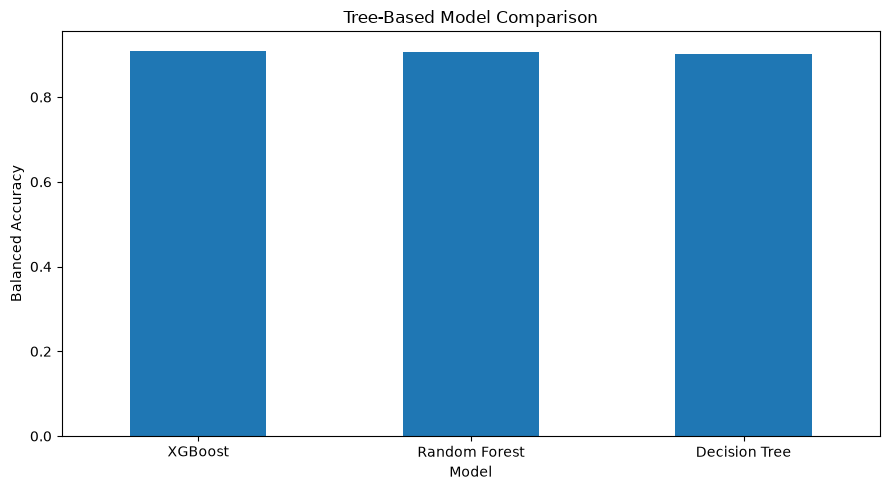

In [32]:
tree_model_comparison_sorted.plot(
    x="Model",
    y="Validation Balanced Accuracy",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Tree-Based Model Comparison")
plt.xlabel("Model")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()

comparison_figure = figures_folder / "tree_based_model_comparison.png"

plt.savefig(comparison_figure)
plt.show()

In [33]:
improved_tree_file = models_folder / "decision_tree_improved.joblib"
random_forest_file = models_folder / "random_forest.joblib"
xgboost_file = models_folder / "xgboost_model.joblib"
label_encoder_file = models_folder / "xgboost_label_encoder.joblib"

joblib.dump(
    decision_tree_model,
    improved_tree_file
)

joblib.dump(
    random_forest_model,
    random_forest_file
)

joblib.dump(
    xgboost_model,
    xgboost_file
)

joblib.dump(
    label_encoder,
    label_encoder_file
)

print("Tree-based models saved successfully")

Tree-based models saved successfully


In [34]:
comparison_file = results_folder / "tree_based_model_comparison.csv"
forest_importance_file = results_folder / "random_forest_feature_importance.csv"
xgboost_importance_file = results_folder / "xgboost_feature_importance.csv"

tree_model_comparison_sorted.to_csv(
    comparison_file,
    index=False
)

forest_importance.to_csv(
    forest_importance_file,
    index=False
)

xgboost_importance.to_csv(
    xgboost_importance_file,
    index=False
)

print("Evaluation results saved successfully")

Evaluation results saved successfully


In [35]:
print("Improved Decision Tree saved")
print(improved_tree_file.exists())

print()

print("Random Forest saved")
print(random_forest_file.exists())

print()

print("XGBoost saved")
print(xgboost_file.exists())

print()

print("XGBoost label encoder saved")
print(label_encoder_file.exists())

print()

print("Comparison results saved")
print(comparison_file.exists())

Improved Decision Tree saved
True

Random Forest saved
True

XGBoost saved
True

XGBoost label encoder saved
True

Comparison results saved
True


## Tree-based model findings

The improved Decision Tree achieved a validation balanced accuracy of 0.9020.

The Random Forest achieved a validation balanced accuracy of 0.9054.

XGBoost achieved the highest validation balanced accuracy of 0.9097.

The XGBoost training balanced accuracy was 0.9113, giving a small generalisation gap of 0.0016.

Random Forest achieved the highest normal accuracy of 0.8927 and the highest Macro F1 score of 0.7787 among the tree-based models.

The most important Random Forest features included `sleep_duration`, `stress_level`, and `physical_activity_level`.

The most important XGBoost features included `stress_level`, `physical_activity_level`, and `sleep_duration`.

XGBoost was the strongest tree-based model according to balanced accuracy.

The next stage is the Artificial Neural Network model.